In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os

In [2]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [4]:
generator = Generator()

generator.load_state_dict(torch.load("./generator.pth"))  # adjust if needed
generator.eval()

print("Generator loaded successfully!")

Generator loaded successfully!


In [5]:
noise = torch.randn(16, 100)   # 16 random inputs
generated_images = generator(noise).detach().numpy()

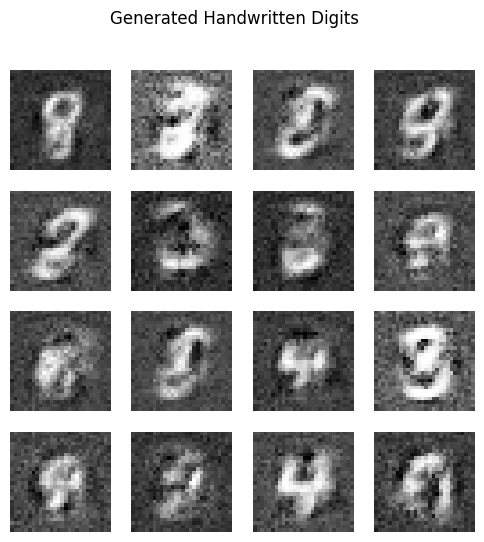

In [6]:
plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Handwritten Digits")
plt.show()

In [7]:
output_dir = "../experiments/gan_samples"
os.makedirs(output_dir, exist_ok=True)

for i in range(16):
    plt.imsave(f"{output_dir}/digit_{i}.png",
               generated_images[i].reshape(28,28),
               cmap='gray')

print("Images saved successfully!")

Images saved successfully!


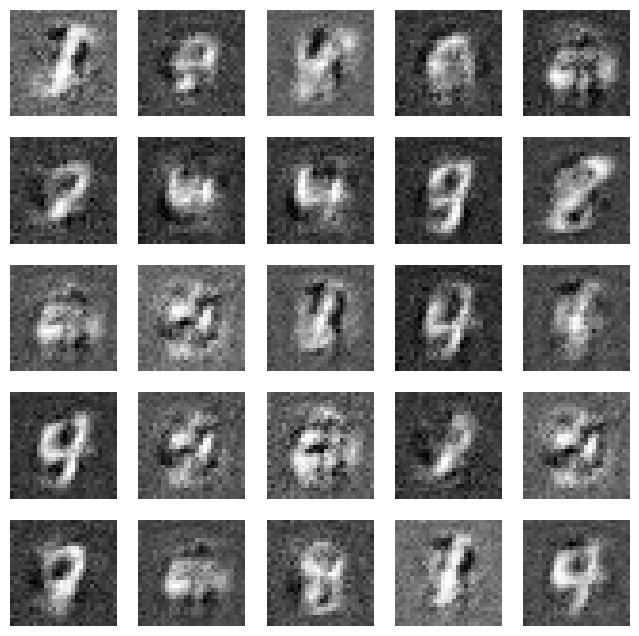

In [8]:
noise = torch.randn(25, 100)
generated_images = generator(noise).detach().numpy()

plt.figure(figsize=(8,8))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(generated_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()